# 👹 AN2DL Challenge 2: The Grumpy Doctogres Challenge

## Notebook 01: Exploratory Data Analysis

This notebook:
- Loads the training and test datasets
- Explores the data distribution
- Visualizes some samples
- Saves processed DataFrames for future use


### Setup

This section sets up the environment by importing necessary libraries and defining data paths.

Finally, it builds DataFrames for training and test datasets by scanning the respective directories for images and masks, and associating labels where applicable.

In [1]:
import os
import random
from concurrent.futures import ThreadPoolExecutor, Future

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from PIL.ImageFile import ImageFile
from tqdm import tqdm

from internal.persistence_manager import PersistenceManager

DATA_DIR = os.path.join('..', 'data')
TRAIN_PATH = os.path.join(DATA_DIR, "train_data")
LABELS_PATH = os.path.join(DATA_DIR, "train_labels.csv")
TEST_PATH = os.path.join(DATA_DIR, "test_data")

print("The data directory is set to:", DATA_DIR)
print("Train data path:", TRAIN_PATH)
print("Labels data path:", LABELS_PATH)
print("Test data path:", TEST_PATH)

# Load labels
labels_df = pd.read_csv(LABELS_PATH)

# Store in dictionary: sample_index -> label
label_map = dict(zip(labels_df["sample_index"], labels_df["label"]))

def build_df(img_dir: str, is_train: bool = True) -> pd.DataFrame:
    """
    Builds a DataFrame from images in `img_dir`.
    - Scans `img_dir` for PNG images (excluding files with 'mask' in the name).
    - For each image, checks mask existence and pulls label from the global `label_map` when `is_train`.
    """
    rows: list = []

    for file_name in sorted(os.listdir(img_dir)):
        if file_name.endswith(".png") and "mask" not in file_name:
            # extract index
            sample_index: str = file_name.replace(".png", "")

            # extract number only
            index: str = sample_index.replace("img_", "")

            # corresponding mask path
            mask_path: str = os.path.join(img_dir, f"mask_{index}.png")

            # collect row
            rows.append({
                "sample_index": sample_index,
                "image_path": os.path.join(img_dir, file_name),
                "mask_path": mask_path if os.path.exists(mask_path) else None,
                "label": label_map.get(file_name) if is_train else None
            })

    return pd.DataFrame(rows)

with (ThreadPoolExecutor() as executor):
    future_train: Future[pd.DataFrame] = executor.submit(build_df, TRAIN_PATH, True)
    future_test: Future[pd.DataFrame]  = executor.submit(build_df, TEST_PATH,  False)

    train_df: pd.DataFrame = future_train.result()
    test_df: pd.DataFrame  = future_test.result()

print(train_df.head())
print(test_df.head())


The data directory is set to: ../data
Train data path: ../data/train_data
Labels data path: ../data/train_labels.csv
Test data path: ../data/test_data
  sample_index                       image_path  \
0     img_0000  ../data/train_data/img_0000.png   
1     img_0001  ../data/train_data/img_0001.png   
2     img_0002  ../data/train_data/img_0002.png   
3     img_0003  ../data/train_data/img_0003.png   
4     img_0004  ../data/train_data/img_0004.png   

                          mask_path            label  
0  ../data/train_data/mask_0000.png  Triple negative  
1  ../data/train_data/mask_0001.png        Luminal A  
2  ../data/train_data/mask_0002.png        Luminal A  
3  ../data/train_data/mask_0003.png        Luminal B  
4  ../data/train_data/mask_0004.png          HER2(+)  
  sample_index                      image_path  \
0     img_0000  ../data/test_data/img_0000.png   
1     img_0001  ../data/test_data/img_0001.png   
2     img_0002  ../data/test_data/img_0002.png   
3     img_00

### Exploratory Data Analysis

This section performs exploratory data analysis (EDA) on the training dataset. It examines label distributions, checks for missing masks, computes image sizes, mask pixel counts, and bounding box areas. Finally, it visualizes a random sample from the dataset.

#### Label Distribution

This part analyzes the distribution of labels in the training dataset. The results show that the classes are relatively balanced, with 'Luminal B' being the most frequent and 'Triple negative' the least.

In [2]:
train_df['label'].value_counts()
train_df['label'].value_counts(normalize=True)

label
Luminal B          0.315156
Luminal A          0.293201
HER2(+)            0.281161
Triple negative    0.110482
Name: proportion, dtype: float64

#### Missing Masks

This part checks for missing masks in the training dataset. It identifies how many samples lack corresponding mask images.

The output indicates that there are no missing masks in the training dataset (1412 samples have masks, 0 do not).

In [3]:
train_df['mask_missing'] = train_df['mask_path'].isnull()
train_df['mask_missing'].value_counts()

mask_missing
False    1412
Name: count, dtype: int64

#### Image and Mask Properties

This section computes and analyzes various properties of the images and masks in the training dataset, including image dimensions, number of mask pixels, and bounding box areas around the masks.

The new columns added are:
- `width`: Width of the image
- `height`: Height of the image
- `mask_pixels`: Number of pixels in the mask
- `bbox_area`: Area of the bounding box around the mask

The descriptive statistics for these new columns provide insights into the distribution of image sizes and mask characteristics in the dataset.

In [4]:
sizes: list[tuple[int, int]] = []
mask_pixels: list[int] = []
bbox_areas: list[np.int64] = []

for _, row in tqdm(train_df.iterrows(), total=len(train_df)):
    # Read image size
    img: ImageFile = Image.open(row["image_path"])
    # Get width and height
    width, height = img.size
    # Store size
    sizes.append((width, height))

    # Open mask image if exists
    mask = Image.open(row["mask_path"]) if row["mask_path"] else None

    # Process mask if exists
    if not mask:
        continue

    # Convert mask to numpy array
    m = np.array(mask)
    # Find non-zero mask pixels
    pos: np.ndarray = np.argwhere(m > 0)

    # Compute bounding box area
    if len(pos) > 0: # If there are mask pixels
        y_min, x_min = pos.min(axis=0)
        y_max, x_max = pos.max(axis=0)
        # The area of the bounding box
        bbox_area: np.int64 = (x_max - x_min) * (y_max - y_min)
        bbox_areas.append(bbox_area)
        mask_pixels.append(pos.shape[0])
    else:
        mask_pixels.append(0)
        bbox_areas.append(np.int64(0))

# Add new columns to DataFrame
# 1. width
train_df["width"] = [s[0] for s in sizes]
# 2. height
train_df["height"] = [s[1] for s in sizes]
# 3. mask_pixels (number of pixels in the mask)
train_df["mask_pixels"] = mask_pixels
# 4. bbox_area (area of the bounding box around the mask)
train_df["bbox_area"] = bbox_areas

train_df.head()

100%|██████████| 1412/1412 [00:06<00:00, 204.37it/s]


,sample_index,image_path,mask_path,label,mask_missing,width,height,mask_pixels,bbox_area
0,img_0000,../data/train_data/img_0000.png,../data/train_data/mask_0000.png,Triple negative,False,1024,1097,12798,522120
1,img_0001,../data/train_data/img_0001.png,../data/train_data/mask_0001.png,Luminal A,False,1024,1221,8859,305256
2,img_0002,../data/train_data/img_0002.png,../data/train_data/mask_0002.png,Luminal A,False,1024,1203,5306,35478
3,img_0003,../data/train_data/img_0003.png,../data/train_data/mask_0003.png,Luminal B,False,1024,1053,30986,506174
4,img_0004,../data/train_data/img_0004.png,../data/train_data/mask_0004.png,HER2(+),False,1024,1404,76667,260352


#### Visualize Sample

Just to get a feel of the data, this part visualizes a random sample from the training dataset, displaying both the image and its corresponding mask side by side.

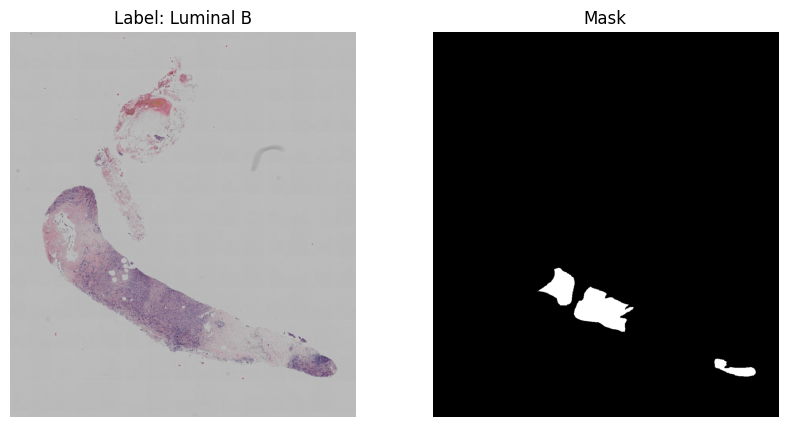

In [5]:
def show_sample(idx: int | None = None):
    if idx is None:
        idx = random.randint(0, len(train_df)-1)

    _row: pd.Series = train_df.iloc[idx]

    _img: np.ndarray = np.array(Image.open(_row["image_path"]))
    _mask: np.ndarray = np.array(Image.open(_row["mask_path"]))

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.title(f"Label: {_row['label']}")
    plt.imshow(_img)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Mask")
    plt.imshow(_mask, cmap="gray")
    plt.axis("off")

    plt.show()

show_sample()

### Descriptive Statistics

This part provides descriptive statistics for the newly added columns in the training DataFrame, giving insights into the distribution of image dimensions, mask pixel counts, and bounding box areas.

#### Image Dimensions

The statistics indicate that the images vary significantly in size, with widths ranging from 1024 to 3970 pixels and heights from 1024 to 4233 pixels. The mean dimensions are approximately 1252x1341 pixels. The standard deviation values suggest a wide spread in image sizes. Additionally, the number of mask pixels and bounding box areas also show considerable variation, reflecting the diversity in the dataset.

In [6]:
train_df[['width','height']].describe()

,width,height
count,1412.000000,1412.000000
mean,1252.313031,1341.359065
std,446.147652,509.641453
min,1024.000000,1024.000000
25%,1024.000000,1024.000000
50%,1024.000000,1097.500000
75%,1294.000000,1468.250000
max,3970.000000,4233.000000


#### Mask Pixels

The statistics for `mask_pixels` show a wide range in the number of pixels covered by the masks, with a mean of approximately 34,220 pixels and a maximum of 355,190 pixels. This indicates significant variability in the size of the regions of interest across different samples. Additionally, the standard deviation is quite high, suggesting that some masks are much larger than others.

Finally, the quartile values indicate that 25% of the samples have masks with fewer than 10,401 pixels, while 75% have masks with fewer than 38,725 pixels, highlighting the skewed distribution of mask sizes in the dataset.


In [7]:
train_df['mask_pixels'].describe()

count      1412.000000
mean      34219.893768
std       42038.650096
min        1727.000000
25%       10401.500000
50%       19104.500000
75%       38725.000000
max      355190.000000
Name: mask_pixels, dtype: float64

#### Bounding Box Area

The statistics for `bbox_area` indicate a wide range of bounding box sizes around the masks, with a mean area of approximately 386,583 square pixels and a maximum area of 1,662,888 square pixels. This suggests significant variability in the size of the regions of interest across different samples. The standard deviation is also quite high, indicating that some bounding boxes are much larger than others. Additionally, the quartile values show that 25% of the samples have bounding box areas smaller than 191,561 square pixels, while 75% have areas smaller than 542,629 square pixels, highlighting the skewed distribution of bounding box sizes in the dataset.

Finally, the minimum bounding box area is 12,483 square pixels, indicating that even the smallest regions of interest are relatively substantial.

In [8]:
train_df['bbox_area'].describe()

count    1.412000e+03
mean     3.865837e+05
std      2.579475e+05
min      1.248300e+04
25%      1.915610e+05
50%      3.438030e+05
75%      5.426298e+05
max      1.662888e+06
Name: bbox_area, dtype: float64

### Save Processed DataFrames

This section saves the processed training and test DataFrames using the `PersistenceManager` for future use in model training and evaluation.

In [9]:
PersistenceManager.save_train_and_test_df({
    "train_df": train_df,
    "test_df": test_df
})

Arrays and scalers saved successfully to: /home/andre/university/AN2DL-Challenge-2/notebooks/processed/train_and_test_df.joblib
